In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm
from matplotlib.ticker import ScalarFormatter

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [ ]:
def initial_state_soliton(x, beta=1, xc=0.0, v=2.0):
    profile = 1.0 / np.cosh(beta * (x - xc))

    A = 1.0 / np.linalg.norm(profile)

    psi = A * profile * np.exp(1j *0.5 * v * (x - xc))

    g = - beta**2 / A**2

    return psi, g, A


def ssfm(psi, g, dt, k, L_half):
    psi = np.fft.ifft(np.fft.fft(psi) * L_half)         
    psi = psi*np.exp(-g*1j * np.abs(psi)**2 * dt)       
    psi = np.fft.ifft(np.fft.fft(psi) * L_half)         

    return psi


def error(psi, psi_exact):
    rho_exact = psi_exact
    rho1 = psi
    error = np.sqrt(np.sum((rho1 - rho_exact)**2) / np.sum(rho_exact**2))
    return error

In [ ]:
n = 8
m4 = 4
m5 = 5
N = 2**n
M4 = 2**m4
M5 = 2**m5
x_max = 10                                              
x = np.linspace(-x_max, x_max, N, endpoint=False)       
dx = x[1] - x[0]                                        


t = 5                                                   
dt = 0.01   
steps = int(t/dt) + 1   

freq = np.fft.fftfreq(N, dx)                           
k = 2 * np.pi * freq                                    
k_shift  = np.fft.fftshift(k)                          
L_half = np.exp(-1j * k**2 * dt/4)                      


In [142]:

psi0, g0, A0 = initial_state_soliton(x, beta=0.5, xc=0.0, v=2.0)
psi1, g1, A1 = initial_state_soliton(x, beta=1, xc=0.0, v=2.0)
psi_exact0density_history = []
psi_exact1density_history = []
times = []                                  

for i in range(steps):
    psi0 = ssfm(psi0, g0, dt, k, L_half)
    psi1 = ssfm(psi1, g1, dt, k, L_half)
    times.append((i + 1)*dt)                      
    psi_exact0density_history.append(np.abs(psi0)**2/A0**2)                                          
    psi_exact1density_history.append(np.abs(psi1)**2/A1**2)

In [143]:
data40 = np.load("qnlse_basis0_n8_m4_shots10_steps500_dt0p01_x_max10.0_run1.npz")
data41 = np.load("qnlse_basis0_n8_m4_shots100_steps500_dt0p01_x_max10.0_run1.npz")
data42 = np.load("qnlse_basis0_n8_m4_shots1000_steps500_dt0p01_x_max10.0_run1.npz")
data43 = np.load("qnlse_basis0_n8_m4_shots10000_steps500_dt0p01_x_max10.0_run1.npz")

data50 = np.load("qnlse_basis0_n8_m5_shots10_steps500_dt0p01_x_max10.0_run1.npz")
data51 = np.load("qnlse_basis0_n8_m5_shots100_steps500_dt0p01_x_max10.0_run1.npz")
data52 = np.load("qnlse_basis0_n8_m5_shots1000_steps500_dt0p01_x_max10.0_run1.npz")
data53 = np.load("qnlse_basis0_n8_m5_shots10000_steps500_dt0p01_x_max10.0_run1.npz")

psi40 = data40["density_history"]/A0**2
psi41 = data41["density_history"]/A0**2
psi42 = data42["density_history"]/A0**2
psi43 = data43["density_history"]/A0**2
#psi4 = data4["density_history"]/A0**2

psi50 = data50["density_history"]/A1**2
psi51 = data51["density_history"]/A1**2
psi52 = data52["density_history"]/A1**2
psi53 = data53["density_history"]/A1**2

psi_m4 = psi_exact0density_history
psi_m5 = psi_exact1density_history

datae = np.load("1D-b-effect.npz")

err_b0p5 = datae["rel_l2_err_b0p5"]  
err_b1 = datae["rel_l2_err_b1"]  


In [144]:
err40_his = []
err41_his = []
err42_his = []
err43_his = []
err44_his = []

err50_his = []
err51_his = []
err52_his = []
err53_his = []

for i in range(len(times)):
    error40 = error(psi40[i], psi_m4[i])
    error41 = error(psi41[i], psi_m4[i])
    error42 = error(psi42[i], psi_m4[i])
    error43 = error(psi43[i], psi_m4[i])
    #error4 = error(psi4[i], psi_exact_n8[i])

    error50 = error(psi50[i], psi_m5[i])
    error51 = error(psi51[i], psi_m5[i])
    error52 = error(psi52[i], psi_m5[i])
    error53 = error(psi53[i], psi_m5[i])


    err40_his.append(error40)
    err41_his.append(error41)
    err42_his.append(error42)
    err43_his.append(error43)
    #err4_his.append(error4)

    err50_his.append(error50)
    err51_his.append(error51)
    err52_his.append(error52)
    err53_his.append(error53)

In [145]:
def sample_points(t, y, n_points):
  
    t = np.asarray(t)
    y = np.asarray(y)

    n_points = min(n_points, len(t))
    idx = np.linspace(0, len(t) - 1, n_points, dtype=int)
    idx = np.unique(idx)

    return t[idx], y[idx]

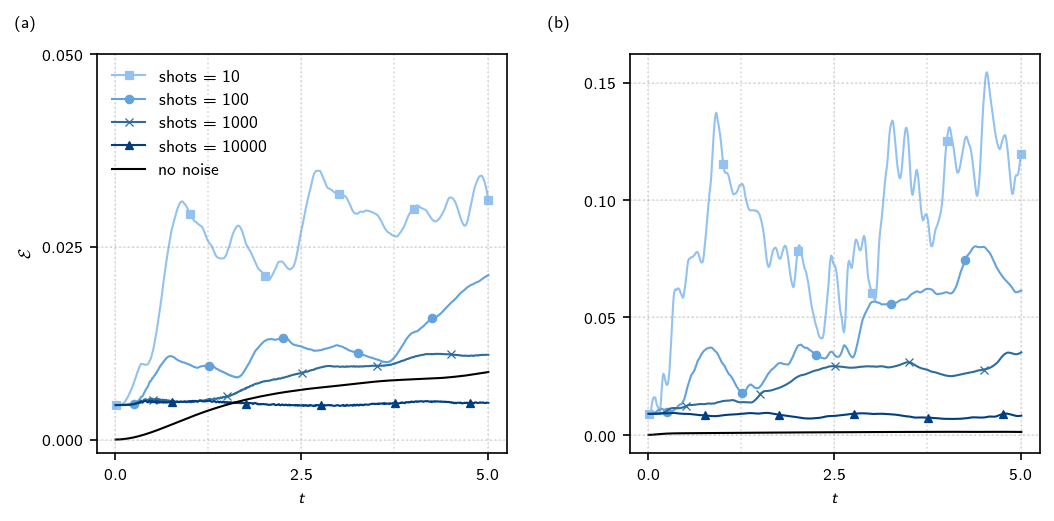

In [ ]:
fontsize = 8
width = 17.9 / 2.54
height = width * 0.5

light_blue = "#93C2F1"
mid_light_blue = "#62A2DD"
mid_blue = "#2C6D9C"
dark_blue = "#003E81"


def add_reference_lines(ax, h_values, v_values,
                        color='0.5', linestyle=':',
                        linewidth=0.8, alpha=0.3):
    for y in h_values:
        ax.axhline(y, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)
    for x in v_values:
        ax.axvline(x, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)


def style_axis(ax, xlabel, ylabel=None,
               xticks=None, yticks=None,
               label_fontsize=fontsize,
               tick_fontsize=fontsize,
               y_sci=False,
               sci_powerlimits=(-2, 2)):
    ax.grid(True, which='both',
            linestyle='--',
            linewidth=0.5,
            color='0.8',
            alpha=0.3)

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(axis='both', labelsize=tick_fontsize)

    if y_sci:
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits(sci_powerlimits)
        ax.yaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis='y', style='sci', scilimits=sci_powerlimits)
def add_panel_label(ax, label, x=-0.2, y=1.1, fontsize=8):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=fontsize,
        va='top', ha='left'
    )


def plot_lines(ax, x, line_specs):
  
    for spec in line_specs:
        ax.plot(
            x,
            spec['y'],
            color=spec.get('color', 'k'),
            linewidth=spec.get('linewidth', 1.0),
            linestyle=spec.get('linestyle', '-'),
            label=spec.get('label', None),
            marker=spec.get('marker', None),
            markersize=spec.get('markersize', None),
            markevery=spec.get('markevery', None),
            markerfacecolor=spec.get('markerfacecolor', None),
            markeredgecolor=spec.get('markeredgecolor', None),
            markeredgewidth=spec.get('markeredgewidth', None),
        )

def setup_panel(ax, x, line_specs, panel_label,
                xlabel=r"$t$", ylabel=None,
                xticks=None, yticks=None,
                hline_values=None, vline_values=None,
                legend=True,
                legend_kwargs=None,
                y_sci=False,
                sci_powerlimits=(-2, 2)):

    plot_lines(ax, x, line_specs)

    style_axis(
        ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xticks=xticks,
        yticks=yticks,
        y_sci=y_sci,
        sci_powerlimits=sci_powerlimits
    )

    if hline_values is not None or vline_values is not None:
        add_reference_lines(
            ax,
            h_values=[] if hline_values is None else hline_values,
            v_values=[] if vline_values is None else vline_values
        )

    if legend:
        if legend_kwargs is None:
            legend_kwargs = {}
        ax.legend(
            frameon=False,
            fontsize=fontsize,
            **legend_kwargs
        )

    add_panel_label(ax, panel_label)



panel_configs = [
    {
        "x": times,
        "line_specs": [
            {"y": err40_his,
                "color": light_blue,
                "linewidth": 1,
                "label":  r"shots = 10",
                "marker": "s",
                "markersize": 4,
                "markevery":(0,100) ,   
                "markerfacecolor": light_blue,
                "markeredgecolor": light_blue,
                "markeredgewidth": 0.6},
            {"y": err41_his, 
                "color": mid_light_blue,
                "linewidth": 1,
                "label":  r"shots = 100",
                "marker": "o",
                "markersize": 4,
                "markevery":(25,100) ,   
                "markerfacecolor": mid_light_blue,
                "markeredgecolor": mid_light_blue,
                "markeredgewidth": 0.6},
            {"y": err42_his, 
                "color": mid_blue,
                "linewidth": 1,
                "label":  r"shots = 1000",
                "marker": "x",
                "markersize": 4,
                "markevery":(50,100) ,   
                "markerfacecolor": mid_blue,
                "markeredgecolor": mid_blue,
                "markeredgewidth": 0.6},
            {"y": err43_his,
                "color": dark_blue,
                "linewidth": 1,
                "label":  r"shots = 10000",
                "marker": "^",
                "markersize": 4,
                "markevery":(75,100) ,   
                "markerfacecolor": dark_blue,
                "markeredgecolor": dark_blue,
                "markeredgewidth": 0.6
            },
            {"y": err_b0p5,
                "color": 'black',
                "linewidth": 1,
                "label":  r"no noise",
                #"marker": "s",
                #"markersize": 4,
                #"markevery":(0,75) ,   
                #"markerfacecolor": light_blue,
                #"markeredgecolor": light_blue,
                #"markeredgewidth": 0.6
                },
        ],
        "panel_label": "(a)",
        "xlabel": r"$t$",
        "ylabel": r"$\mathcal{E}$",
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0, 0.05, 3),
        "hline_values": np.linspace(0, 0.05, 3),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
        "legend": True,
            "legend_kwargs": {
            "loc": "upper left",
            },
    },
    {
        "x": times,
        "line_specs": [
            {
                "y": err50_his,
                "color": light_blue,
                "linewidth": 1,
                "label":  r"shots = 10",
                "marker": "s",
                "markersize": 4,
                "markevery":(0,100) ,   
                "markerfacecolor": light_blue,
                "markeredgecolor": light_blue,
                "markeredgewidth": 0.6
            },
            {
                "y": err51_his,
                "color": mid_light_blue,
                "linewidth": 1,
                #"linestyle": "none",
                "label": r"shots = 100",
                "marker": "o",
                "markersize": 4,
                "markevery": (25,100),  
                "markerfacecolor": mid_light_blue,
                "markeredgecolor": mid_light_blue,
                "markeredgewidth": 0.6
            },
            {
                "y": err52_his,
                "color": mid_blue,
                "linewidth": 1,
                #"linestyle": "none",
                "label": r"shots = 1000",
                "marker": "x",
                "markersize": 4,
                "markevery": (50,100) ,
                "markerfacecolor": mid_blue,
                "markeredgecolor": mid_blue,
                "markeredgewidth": 0.6
            },
            {"y": err53_his, 
                "color": dark_blue,
                "linewidth": 1,
                #"linestyle": "none",
                "label": r"shots = 10000",
                "marker": "^",
                "markersize": 4,
                "markevery": (75,100) ,
                "markerfacecolor": dark_blue,
                "markeredgecolor": dark_blue,
                "markeredgewidth": 0.6
            },
            {"y": err_b1,
                "color": 'black',
                "linewidth": 1,
                "label":  r"no noise",
                #"marker": "s",
                #"markersize": 4,
                #"markevery":(0,75) ,   
                #"markerfacecolor": 'black',
                #"markeredgecolor": 'black',
                #"markeredgewidth": 0.6
                },
        ],
        "panel_label": "(b)",
        "xlabel": r"$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0, 0.15, 4),
        "hline_values": np.linspace(0, 0.15, 4),
        "vline_values": np.linspace(0, 5, 5),
        "legend": False,
        "y_sci": True,
        "sci_powerlimits": (-2, 2),
    },
]


def main():
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

    for ax, cfg in zip(axes, panel_configs):
        setup_panel(
        ax=ax,
        x=cfg["x"],
        line_specs=cfg["line_specs"],
        panel_label=cfg["panel_label"],
        xlabel=cfg["xlabel"],
        ylabel=cfg["ylabel"],
        xticks=cfg["xticks"],
        yticks=cfg["yticks"],
        hline_values=cfg["hline_values"],
        vline_values=cfg["vline_values"],
        legend=cfg["legend"],
        legend_kwargs=cfg.get("legend_kwargs", None),
        y_sci=cfg.get("y_sci", False),
        sci_powerlimits=cfg.get("sci_powerlimits", (-2, 2)),
)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)

    plt.savefig("1D_noise.svg", dpi=300,bbox_inches="tight", pad_inches=0.02)
    plt.savefig("1D_noise.pdf", dpi=300,bbox_inches="tight", pad_inches=0.02)
    # plt.show()


if __name__ == "__main__":
    main()